<a href="https://colab.research.google.com/github/mahfuz640/Credit-Card-Fraud-Detection-By-Machine-Learning-/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
kaggle datasets download mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0



100%|██████████| 66.0M/66.0M [00:02<00:00, 25.4MB/s]


In [ ]:
%%bash
unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
display(df.describe())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


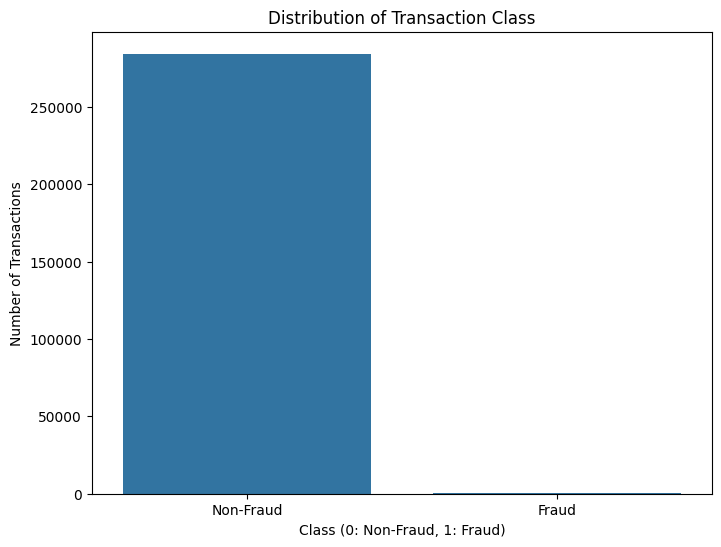

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transaction Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

In [ ]:
# Filter the DataFrame to show only fraudulent transactions (Class = 1)
fraudulent_transactions = df[df['Class'] == 1]

# Display the first 5 fraudulent transactions
display(fraudulent_transactions.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


### 1. Data Preprocessing: Scaling 'Time' and 'Amount'

The 'Time' and 'Amount' columns have not been scaled, unlike the 'V' features which are the result of a PCA transformation. It's crucial to scale these features to ensure they contribute equally to the model's performance. We'll use `StandardScaler` from `sklearn.preprocessing` for this task.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Make a copy of the original DataFrame to avoid modifying it directly
df_scaled = df.copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the 'Amount' column
df_scaled['Amount'] = scaler.fit_transform(df_scaled['Amount'].values.reshape(-1, 1))

# Scale the 'Time' column
df_scaled['Time'] = scaler.fit_transform(df_scaled['Time'].values.reshape(-1, 1))

# Display the first few rows of the scaled DataFrame to verify
print("DataFrame after scaling 'Time' and 'Amount' columns:")
display(df_scaled.head())

DataFrame after scaling 'Time' and 'Amount' columns:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


### 2. Handling Imbalanced Dataset: Random Under-sampling

Given the significant class imbalance, where fraudulent transactions are a tiny fraction of the total, training a model directly on this data can lead to poor performance on the minority class. To mitigate this, we will use **Random Under-sampling** to reduce the number of majority class samples (non-fraudulent transactions) to be equal to the number of minority class samples (fraudulent transactions). This will create a balanced dataset for model training. We will use the `RandomUnderSampler` from the `imblearn.under_sampling` library.

Class distribution after Random Under-sampling:
Class
0    492
1    492
Name: count, dtype: int64


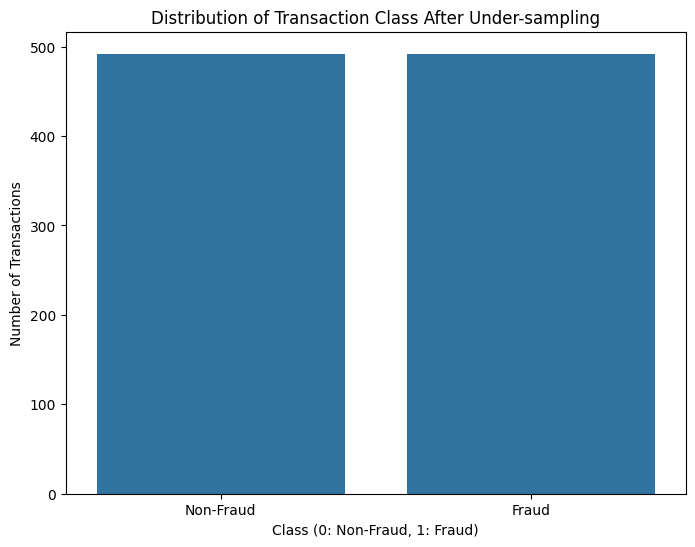

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# Define features (X) and target (y)
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

# Initialize RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Perform under-sampling
X_resampled, y_resampled = rus.fit_resample(X, y)

# Display the new class distribution
print("Class distribution after Random Under-sampling:")
print(y_resampled.value_counts())

# Plot the new distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribution of Transaction Class After Under-sampling')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

### 3. Splitting the Data into Training and Testing Sets

To properly evaluate our fraud detection model, we need to split our balanced dataset (`X_resampled`, `y_resampled`) into training and testing subsets. The training set will be used to teach the model, and the testing set will be used to assess its performance on data it has not seen before. We'll use `train_test_split` from `sklearn.model_selection` for this, ensuring a consistent split with `random_state`.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

# Display the shapes of the new datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

Shape of X_train: (688, 30)
Shape of X_test: (296, 30)
Shape of y_train: (688,)
Shape of y_test: (296,)

Class distribution in y_train:
Class
1    344
0    344
Name: count, dtype: int64

Class distribution in y_test:
Class
0    148
1    148
Name: count, dtype: int64


### 4. Model Training: Logistic Regression

With our data scaled, balanced, and split, we can now train a classification model. Logistic Regression is a simple yet powerful algorithm often used as a baseline for binary classification problems. We'll train it on our `X_train` and `y_train` data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set class_weight='balanced' in case we missed perfect balancing or for robustness
# C is the inverse of regularization strength; smaller values specify stronger regularization.
model = LogisticRegression(solver='liblinear', C=1.0, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 5. Model Evaluation

After training our Logistic Regression model, it's crucial to evaluate its performance on the test set. We'll use several metrics to understand how well the model detects fraudulent transactions, especially considering the nature of the problem where correctly identifying fraud (high recall) is often more important than overall accuracy.

Accuracy: 0.9459
Precision: 0.9583
Recall: 0.9324
F1-Score: 0.9452

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       148
           1       0.96      0.93      0.95       148

    accuracy                           0.95       296
   macro avg       0.95      0.95      0.95       296
weighted avg       0.95      0.95      0.95       296



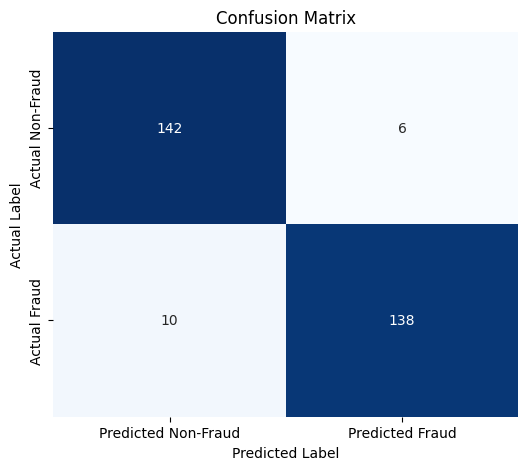

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 6. Demonstrating Fraud Detection with a New Transaction

Let's simulate a new transaction and use our trained model to predict if it's fraudulent.

In [ ]:
# Create a hypothetical new transaction (all V-features are already scaled)
# We will use some values similar to a fraudulent transaction for demonstration
new_transaction_data = {
    'Time': [123456.0], # A hypothetical time, will be scaled
    'V1': [-2.312227],
    'V2': [1.951992],
    'V3': [-1.609851],
    'V4': [3.997906],
    'V5': [-0.522188],
    'V6': [-1.426545],
    'V7': [-2.531022],
    'V8': [1.391657],
    'V9': [-2.770089],
    'V10': [-2.772272],
    'V11': [3.376269],
    'V12': [-2.458775],
    'V13': [0.203671],
    'V14': [-1.088143],
    'V15': [0.523098],
    'V16': [-0.035049],
    'V17': [-0.603008],
    'V18': [-0.590529],
    'V19': [0.346102],
    'V20': [0.155468],
    'V21': [0.517232],
    'V22': [-0.035049],
    'V23': [-0.697670],
    'V24': [-0.030691],
    'V25': [0.101712],
    'V26': [-0.370427],
    'V27': [-0.370427],
    'V28': [-0.062978],
    'Amount': [239.93] # A hypothetical amount, will be scaled
}

new_transaction_df = pd.DataFrame(new_transaction_data)

# Preprocess the new transaction (scaling Time and Amount)
# We need to use the *same* scaler fitted on the original training data
# IMPORTANT: Do not refit the scaler; just transform

# Ensure the 'scaler' object is available from previous steps
# If not, you might need to re-run the scaling cell or save the scaler.
# Assuming 'scaler' from cell 'fa820c7d' is in scope.
new_transaction_df['Time'] = scaler.transform(new_transaction_df['Time'].values.reshape(-1, 1))
new_transaction_df['Amount'] = scaler.transform(new_transaction_df['Amount'].values.reshape(-1, 1))

display(new_transaction_df)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.603144,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.531022,1.391657,-2.770089,...,0.155468,0.517232,-0.035049,-0.69767,-0.030691,0.101712,-0.370427,-0.370427,-0.062978,-1.991531


In [ ]:
# Make a prediction using the trained model
prediction = model.predict(new_transaction_df)

print(f"The model predicts this transaction is: {'Fraudulent' if prediction[0] == 1 else 'Non-Fraudulent'}")

if prediction[0] == 1:
    print("This transaction is flagged as potential fraud.")
else:
    print("This transaction is considered legitimate.")

The model predicts this transaction is: Fraudulent
This transaction is flagged as potential fraud.
